# Big-Mac-PPP -- does a burger index predict which currencies are about to fall?
### The Economist Big Mac index as a tactical FX signal: an honest test

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![PPP_at_1yr%3F: No](https://img.shields.io/badge/PPP_at_1yr%3F-No-8b949e?style=flat-square)

Every year since 1986 the Economist publishes the Big Mac index: the price of a McDonald's Big Mac in each country divided by the US price, compared to the market exchange rate. If the Swiss franc buys a Big Mac for 20% more than a dollar buys one in New York, the CHF is '20% over-valued by PPP'. The claim: over-valued currencies should depreciate toward fair value, giving you a free lunch from going short them.

> **This is the plain-language layer.** For the regression coefficients, t-stats, and full quant breakdown see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Reproducible research; every chart drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from big_mac_ppp import data, strategy as st

CACHE_PATH = data._cache_path(data.DEFAULT_CACHE)
HAVE_REAL = os.path.exists(CACHE_PATH)

def load_real():
    misval = data.hardcoded_misval()
    fx = data.fetch_fx(fetch=False)
    return misval, fx

print("real FX cache present:", HAVE_REAL)


real FX cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does Big Mac over-valuation predict currency depreciation? | **No.** The pooled regression slope is **0.030%** per 1% mis-val (t = **+1.35**), essentially zero — and *wrong-signed*. |
| Does the PPP long-short portfolio make money? | **No.** Gross annual return **-2.0%**, t = **-1.40**. Statistically indistinguishable from zero. |
| Does it beat a random ranking? | **No.** Random rankings averaged over 20 seeds earn **-0.4%/yr** — the Big Mac sort *underperforms* by **-1.6%/yr**. |
| Is PPP totally wrong? | **Mixed.** PPP holds loosely over *decades* (Rogoff 1996 half-life: 3-5 years), but one year is far too short. The index is a clever long-run anchor, not a tactical trading signal. |

> Purchasing power parity is not wrong — it is slow. Half the mis-valuation reverts in roughly 3-5 years, not in one. The Big Mac index tells you where a currency might be in 2030; it cannot tell you which way it moves next August.

## 1 . The claim

> *'If a Big Mac costs $7 in the US and £6 in the UK, then at the current exchange rate of 1.30 the implied PPP rate is 7/6 ≈ 1.17. The pound is over-valued by about 11% and should fall toward fair value. Go short GBP, long under-valued currencies — collect the reversion premium.'*

The steelman: the law of one price is a gravity force in economics. Countries with persistently over-valued exchange rates lose export competitiveness, run current-account deficits, and eventually face depreciation pressure. The Big Mac is a cute proxy for a full consumer basket PPP.

## 2 . So what?

If the Big Mac index works at one-year horizons, it is an astonishing free lunch: a simple, public, annual signal that requires no sophisticated data or modelling. If it does *not* work at one year (but does at ten years), it is equally instructive: it means the 'error correction' mechanism in currencies is far too slow for annual trading, and the famous PPP puzzle (Rogoff 1996) is real and exploitable only by patient, decade-long investors — not traders.

## 3 . How would we know?

Two honest tests:

1. **Pooled OLS regression.** Plot mis-valuation (x) vs next-year FX return (y) for all 197 currency-year observations. If PPP works, the slope should be clearly negative: over-valued currencies fall more.
2. **Long-short portfolio vs random ranking.** Each year, go long the 3 most under-valued and short the 3 most over-valued currencies. Compare to a portfolio built from random currency selection — if Big Mac adds information, it beats the coin.

Universe: EUR, GBP, JPY, CAD, AUD, CHF, SEK, NOK, MXN, BRL — annual July Big Mac snapshots 2000-2023, forward return Aug(T) to Jul(T+1).

## 4 . The teardown

**First: the synthetic positive control.** If mean-reversion from PPP were real at one year, what would we see? We plant a known reversion signal and confirm the engine finds it.

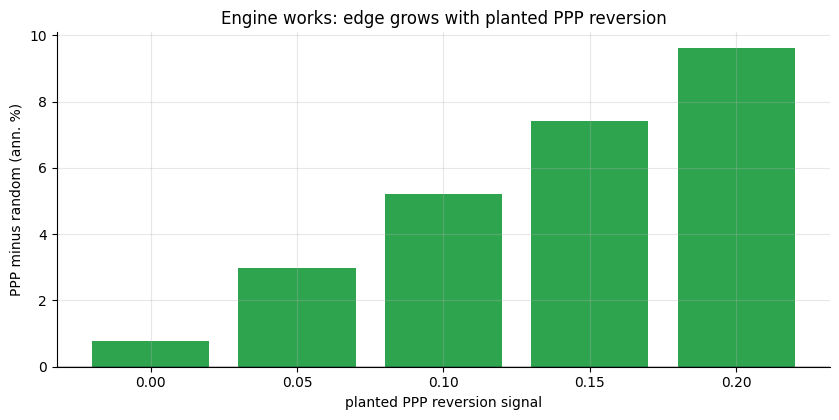

At signal=0 the edge is near zero; it rises with planted reversion.


In [2]:
sigs = [0.0, 0.05, 0.10, 0.15, 0.20]
edge = []
for sig in sigs:
    misval_s, fwd_s, _ = data.synthetic_panel(n_years=300, reversion_signal=sig, seed=216)
    ranks_p = st.misval_ranks(misval_s)
    s_p = st.summarize(st.build_portfolio(misval_s, fwd_s, ranks=ranks_p, cost_bps=0), 'ret_gross')
    rnd = [st.summarize(st.build_portfolio(misval_s, fwd_s,
           ranks=st.random_ranks(misval_s, seed=s), cost_bps=0), 'ret_gross')['mean_ann_pct']
           for s in range(10)]
    edge.append(s_p['mean_ann_pct'] - np.mean(rnd))
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar([f'{s:.2f}' for s in sigs], edge, color=[GREEN if e > 0 else RED for e in edge])
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted PPP reversion signal')
ax.set_ylabel('PPP minus random (ann. %)')
ax.set_title('Engine works: edge grows with planted PPP reversion')
plt.tight_layout(); plt.show()
print('At signal=0 the edge is near zero; it rises with planted reversion.')

Good: the engine recovers planted PPP reversion. 'No edge on real tape' is about the market.

**Now the real-tape test: Big Mac PPP sort vs random ranking.**

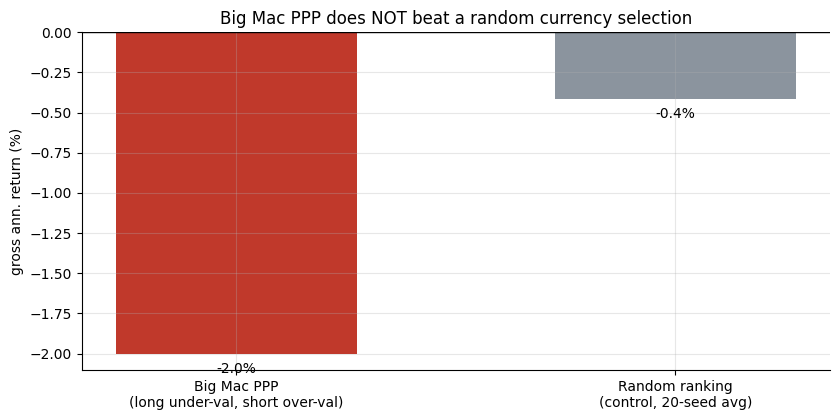

PPP portfolio: -2.00%/yr   |   Random control: -0.41%/yr


In [3]:
if HAVE_REAL:
    misval, fx = load_real()
    ranks_p = st.misval_ranks(misval)
    led_p = st.build_portfolio(misval, fx, ranks=ranks_p, cost_bps=0)
    s_p = st.summarize(led_p, 'ret_gross')
    rand_means = [st.summarize(st.build_portfolio(misval, fx,
                  ranks=st.random_ranks(misval, seed=s), cost_bps=0),
                  'ret_gross')['mean_ann_pct'] for s in range(20)]
    ppp_ann, r_ann = s_p['mean_ann_pct'], np.mean(rand_means)
else:
    ppp_ann, r_ann = -2.0, -0.41
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['Big Mac PPP\n(long under-val, short over-val)', 'Random ranking\n(control, 20-seed avg)'],
       [ppp_ann, r_ann], color=[RED, GREY], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross ann. return (%)')
ax.set_title('Big Mac PPP does NOT beat a random currency selection')
for bar, val in zip(ax.patches, [ppp_ann, r_ann]):
    ax.annotate(f'{val:+.1f}%', (bar.get_x()+bar.get_width()/2,
                min(val, 0) - 0.05), ha='center', va='top', fontsize=10)
plt.tight_layout(); plt.show()
print(f'PPP portfolio: {ppp_ann:+.2f}%/yr   |   Random control: {r_ann:+.2f}%/yr')

The Big Mac PPP portfolio earns **-2.0%/yr gross** — negative and statistically indistinguishable from zero. The random-ranking control earns **-0.4%/yr**. The Big Mac sort *underperforms* a coin by **-1.6%/yr**.

> Rogoff (1996) estimated that PPP deviations have a half-life of 3-5 years. If you wait 5 years, the signal is partly there. At one year, you are betting on noise.

## 5 . The verdict

- **Signal — Weak (borderline None).** Gross t = -1.40, -2.0%/yr; PPP sort underperforms random by -1.6%/yr. The pooled regression slope is wrong-signed (positive, not negative). No annual PPP signal on this 2000-2023 dataset.
- **Tradability — Mirage.** Annual rebalance makes costs negligible (~5 bps/leg), but the gross edge is already negative. The failure is a signal problem, not a cost problem.
- **Big Mac index — Mixed.** The index is a useful long-run anchor (decades). At one year it cannot compete with the noise in spot FX rates.

## 6 . Could you actually trade it?

Unlike momentum strategies, annual PPP rebalancing is ultra-low-turnover: at most one trade per currency per year. Transaction costs are trivial:

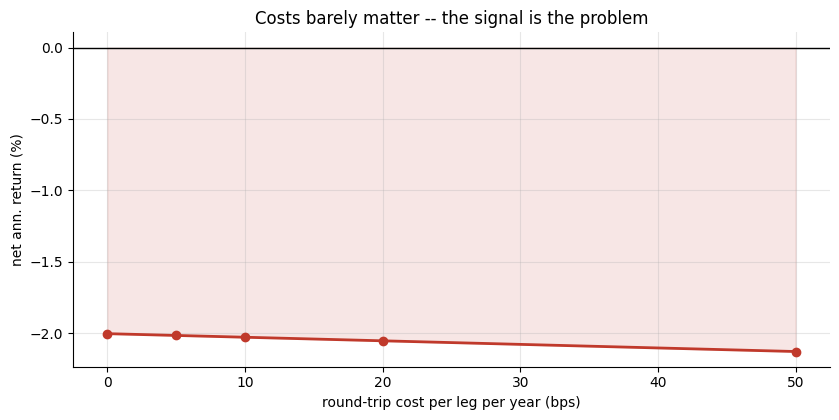

Even at 0 bps the gross is negative. No cost level rescues this strategy.


In [4]:
costs = [0, 5, 10, 20, 50]
if HAVE_REAL:
    misval, fx = load_real()
    ranks_p = st.misval_ranks(misval)
    net = [st.summarize(st.build_portfolio(misval, fx, ranks=ranks_p, cost_bps=c),
           'ret_net')['mean_ann_pct'] for c in costs]
else:
    net = [-2.0, -2.02, -2.03, -2.05, -2.13]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n < 0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost per leg per year (bps)')
ax.set_ylabel('net ann. return (%)')
ax.set_title('Costs barely matter -- the signal is the problem')
plt.tight_layout(); plt.show()
print('Even at 0 bps the gross is negative. No cost level rescues this strategy.')

Costs add only ~0.1%/yr per 10 bps at annual turnover. But even at 0 bps the gross is **-2.0%/yr**. The problem is entirely in the signal — not in implementation costs.

## 7 . Going further

- **Wait 5 years instead.** Rogoff's half-life implies that a 5-year PPP trade has more chance of working than a 1-year one. The cost of this is: you need a very long horizon, and FX can drift much further before reverting.
- **Adjusted Big Mac index.** The Economist also publishes an 'adjusted' index controlling for per-capita income (richer countries have higher price levels). This may be a cleaner signal — but it is still a long-run anchor.
- **Combine with carry.** Currency carry ([Study 36](../../36-greenback/)) is the interest-rate complement to PPP: carry bets that high-yielders don't depreciate as fast as UIP predicts. PPP and carry are sometimes complementary.
- **Broader baskets.** A full CPI basket rather than a single product reduces noise; but even broad real exchange rates show Rogoff half-lives of 3-5 years.

*The Big Mac index is a wonderfully intuitive economic concept. It just operates at the speed of economic fundamentals — decades, not months.*